In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import joblib

In [2]:
data_prefix = "../0_data/processed_data/"
model_types = ['LGB']
label = 'MP_label'
non_feature_cols = ['SMILES', 'MP', 'Type'] + [label]
data_types = ['L', 'H', 'All']

In [ ]:
def model_development(data, non_feature_cols, model_type, trials):

    X = data.drop(columns=non_feature_cols)
    y = data['MP'].values
    strat_labels = data[label].values

    # Precompute folds stratified on label (not continuous MP)
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    folds = list(skf.split(X, strat_labels))

    # ── Helper: run 10-fold CV for a given model instance ─────────────
    def run_cv(model_instance):
        fold_rmses = []
        for train_idx, val_idx in folds:
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            model_instance.fit(X_train, y_train)
            preds = model_instance.predict(X_val)
            fold_rmses.append(np.sqrt(mean_squared_error(y_val, preds)))
        return fold_rmses

    # ── Model + search space definitions ──────────────────────────────
    if model_type == 'RF':
        default_model = RandomForestRegressor(random_state=42, n_jobs=-1)
        base_model    = RandomForestRegressor(random_state=42, n_jobs=-1)
        search_space  = {
            'n_estimators':      Integer(20, 500),
            'max_depth':         Integer(3,    12),
            'min_samples_split': Integer(2,    10),
            'min_samples_leaf':  Integer(1,    10),
            'max_features':      Real(0.1, 1.0),
        }

    elif model_type == 'LGB':
        default_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
        base_model    = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
        search_space  = {
            'num_leaves':        Integer(20,   300),
            'max_depth':         Integer(3,    12),
            'learning_rate':     Real(0.01, 0.3,   prior='log-uniform'),
            'n_estimators':      Integer(20, 500),
            'min_child_samples': Integer(10,   50),
            'subsample':         Real(0.6, 1.0),
            'colsample_bytree':  Real(0.4, 1.0),
            'reg_alpha':         Real(1e-5, 10.0,  prior='log-uniform'),
            'reg_lambda':        Real(1e-5, 10.0,  prior='log-uniform'),
        }

    elif model_type == 'XGB':
        default_model = xgb.XGBRegressor(random_state=42, n_jobs=-1,
                                          tree_method='hist', verbosity=0)
        base_model    = xgb.XGBRegressor(random_state=42, n_jobs=-1,
                                          tree_method='hist', verbosity=0)
        search_space  = {
            'n_estimators':      Integer(20, 500),
            'max_depth':         Integer(3,    12),
            'learning_rate':     Real(0.01, 0.3,  prior='log-uniform'),
            'subsample':         Real(0.6, 1.0),
            'colsample_bytree':  Real(0.4, 1.0),
            'reg_alpha':         Real(1e-5, 10.0, prior='log-uniform'),
            'reg_lambda':        Real(1e-5, 10.0, prior='log-uniform'),
            'min_child_weight':  Integer(1,   10),
        }

    else:
        raise ValueError(f"model_type must be 'RF', 'LGB', or 'XGB'; got '{model_type}'")

    # ── Trial 0: default hyperparameters ──────────────────────────────
    trial_results = {}
    fold_rmses_0 = run_cv(default_model)
    mean_0 = float(np.mean(fold_rmses_0))
    std_0  = float(np.std(fold_rmses_0))
    trial_results[0] = {'fold_rmses': fold_rmses_0, 'mean_rmse': mean_0, 'std_rmse': std_0}
    print(f"Trial  0 (default) | mean RMSE: {mean_0:.4f} ± {std_0:.4f}")

    # ── Trials 1-20: BayesSearchCV ────────────────────────────────────
    # Pass precomputed folds as cv so BayesSearchCV never calls
    # StratifiedKFold.split(X, y) with a continuous y (which would error).
    opt = BayesSearchCV(
        base_model,
        search_space,
        n_iter=20,
        cv=folds,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=1,
        refit=True,
    )
    opt.fit(X, y)

    # Extract per-trial fold RMSEs from cv_results_ (negate the neg-RMSE scores)
    n_splits = len(folds)
    for i in range(trials):
        fold_rmses = [-opt.cv_results_[f'split{s}_test_score'][i] for s in range(n_splits)]
        mean_rmse  = float(np.mean(fold_rmses))
        std_rmse   = float(np.std(fold_rmses))
        trial_results[i + 1] = {
            'fold_rmses': fold_rmses,
            'mean_rmse':  mean_rmse,
            'std_rmse':   std_rmse,
        }
        print(f"Trial {i+1:>2d} | mean RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")


    return trial_results, opt.best_estimator_

In [4]:
for model in model_types:

    for data_type in data_types:
        
        data = pd.read_parquet(data_prefix + f"data_with_selected_features_{model}_{data_type}_scaled.parquet")
        data = data[data['Type'] == 'Train'].reset_index(drop=True)

        if data_type != 'All':
            data = data[data[label] == data_type].reset_index(drop=True)
            
        print(f"\n=== Model: {model} ===")
        print(f"=== Data Type: {data_type} ===")
        # print the number of data and features
        print(f"Dataset shape: {data.shape} (n_samples={data.shape[0]}, n_features={data.shape[1] - len(non_feature_cols)})")
        trial_results, best_model = model_development(data, non_feature_cols, model_type=model, trials=20)

        import pickle
        with open(f'model_development_results_{model}_{data_type}.pkl', 'wb') as f:
            pickle.dump(trial_results, f)
        joblib.dump(best_model, f"best_model_{model}_{data_type}.joblib",compress = 3)



=== Model: LGB ===
=== Data Type: L ===
Dataset shape: (11439, 93) (n_samples=11439, n_features=89)
Trial  0 (default) | mean RMSE: 34.1538 ± 1.1195
Trial  1 | mean RMSE: 33.2406 ± 1.3257
Trial  2 | mean RMSE: 33.6481 ± 1.5219
Trial  3 | mean RMSE: 34.9328 ± 1.2307
Trial  4 | mean RMSE: 34.8242 ± 1.0792
Trial  5 | mean RMSE: 32.9808 ± 1.1500
Trial  6 | mean RMSE: 34.0676 ± 1.3525
Trial  7 | mean RMSE: 33.5243 ± 1.2829
Trial  8 | mean RMSE: 34.0725 ± 1.3025
Trial  9 | mean RMSE: 32.8643 ± 1.2033
Trial 10 | mean RMSE: 33.5009 ± 1.0793
Trial 11 | mean RMSE: 33.4071 ± 1.1935
Trial 12 | mean RMSE: 35.2438 ± 1.1475
Trial 13 | mean RMSE: 33.3220 ± 1.2695
Trial 14 | mean RMSE: 32.9384 ± 1.2065
Trial 15 | mean RMSE: 34.9077 ± 1.1469
Trial 16 | mean RMSE: 33.9804 ± 1.1972
Trial 17 | mean RMSE: 33.0502 ± 1.2229
Trial 18 | mean RMSE: 32.8995 ± 1.2360
Trial 19 | mean RMSE: 33.0418 ± 1.2866
Trial 20 | mean RMSE: 33.1707 ± 1.2271

=== Model: LGB ===
=== Data Type: H ===
Dataset shape: (615, 59) (n_s

In [ ]:
import matplotlib.pyplot as plt

def plot_model_performance(model_development_results_dict):
    """
    Plot mean RMSE ± std as a function of HP tuning iteration.

    Parameters
    ----------
    model_development_results_dict : dict
        The trial_results dict returned by model_development().
        Keys = trial number (0 = default HP, 1-20 = BayesSearchCV iterations).
        Values = {'mean_rmse': float, 'std_rmse': float, ...}
    """
    trials     = sorted(model_development_results_dict.keys())
    mean_rmses = [model_development_results_dict[t]['mean_rmse'] for t in trials]
    std_rmses  = [model_development_results_dict[t]['std_rmse']  for t in trials]

    mean_rmses = np.array(mean_rmses)
    std_rmses  = np.array(std_rmses)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(trials, mean_rmses, marker='o', linewidth=1.5, color='steelblue', label='Mean RMSE')
    ax.fill_between(trials,
                    mean_rmses - std_rmses,
                    mean_rmses + std_rmses,
                    alpha=0.25, color='steelblue', label='± 1 std')

    # Mark trial 0 (default HP) distinctly
    ax.axvline(x=0, color='grey', linestyle='--', linewidth=1, label='Default HP (trial 0)')

    # Highlight best trial
    best_trial = trials[int(np.argmin(mean_rmses))]
    best_rmse  = min(mean_rmses)
    ax.scatter([best_trial], [best_rmse], color='red', zorder=5,
               label=f'Best (trial {best_trial}, RMSE={best_rmse:.4f})')

    ax.set_xlabel('HP Tuning Iteration', fontsize=12)
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_title('Model Performance vs. HP Tuning Iteration', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


=== Performance plot for LGB (L) ===


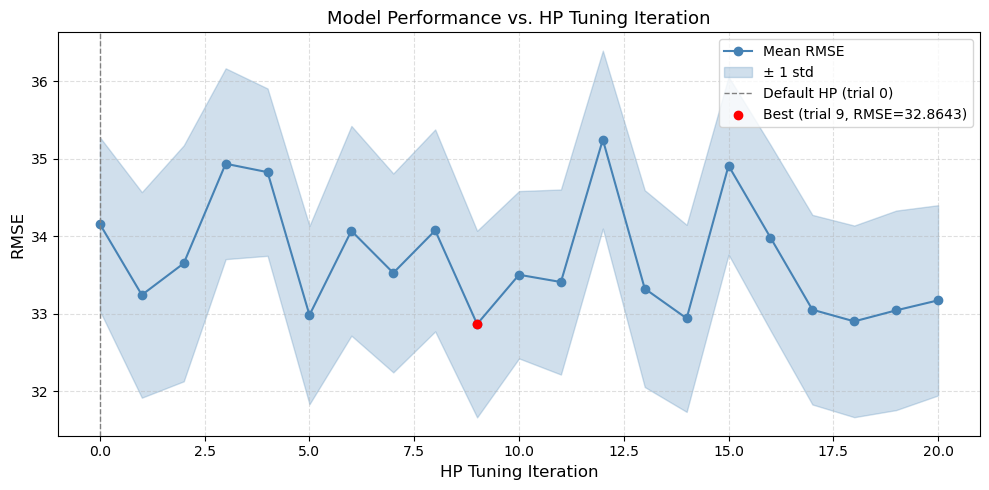


=== Performance plot for LGB (H) ===


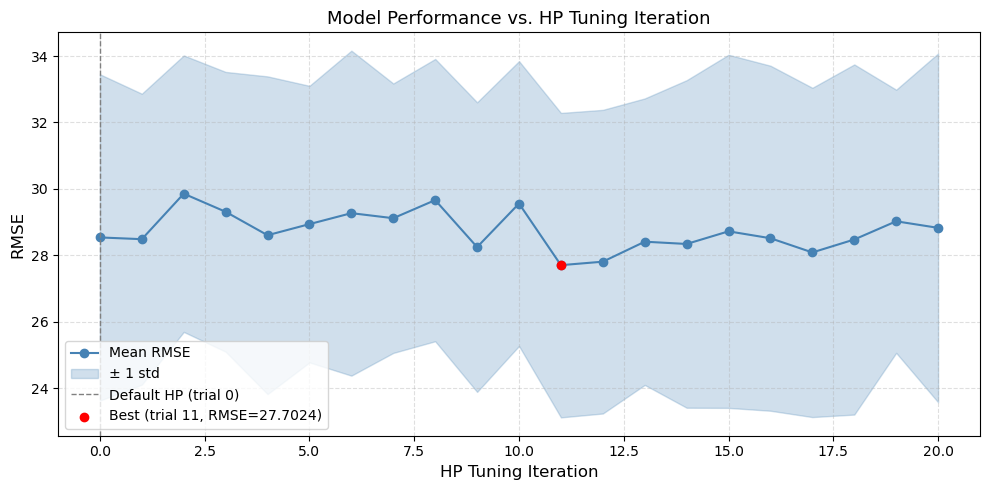


=== Performance plot for LGB (All) ===


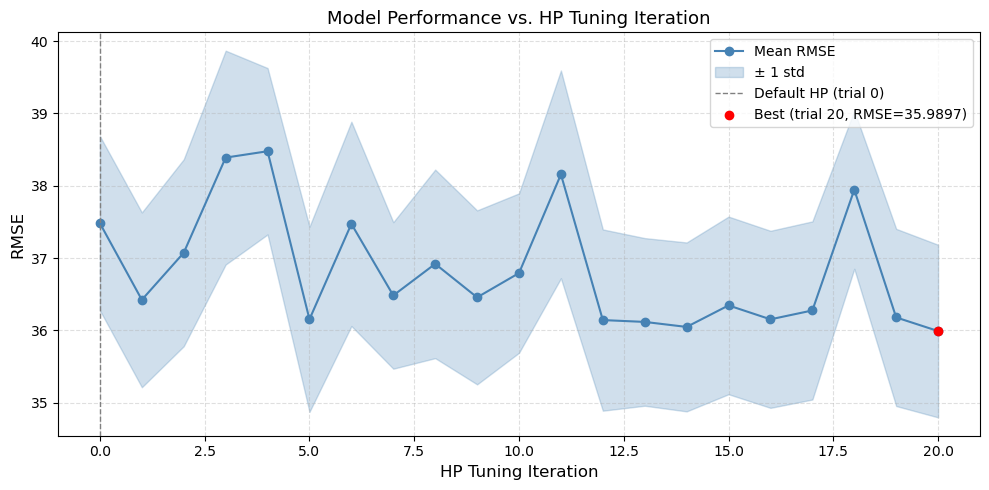

In [6]:
for model in model_types:

    for data_type in data_types:

        print(f"\n=== Performance plot for {model} ({data_type}) ===")

        with open(f'model_development_results_{model}_{data_type}.pkl', 'rb') as f:
            model_development_results = pickle.load(f)

        plot_model_performance(model_development_results)